# CAMB & CosmoPower: a hands-on tutorial (+ a `cloelib` example)

This notebook is written to run top-to-bottom in **Google Colab** (`Runtime > Run all`).
It has three parts:

1. **[CAMB](https://camb.readthedocs.io)** — the Boltzmann code that numerically evolves the linear
   (and, via halofit/HMcode, non-linear) cosmological perturbation equations to predict the CMB
   power spectra and the matter power spectrum $P(k)$ from first principles. It is accurate but
   each call costs a fraction of a second to a few seconds.
2. **[CosmoPower](https://github.com/alessiospuriomancini/cosmopower)** — neural-network emulators
   trained to reproduce CAMB/CLASS outputs to sub-percent accuracy, but ~1000&times; faster, because
   a forward pass through a small NN replaces solving the Boltzmann hierarchy. This is what makes
   CAMB-quality theory practical inside MCMC/nested-sampling loops for next-generation surveys
   (like Euclid).
3. **[`cloelib`](https://github.com/cloe-org/cloelib)** — the Euclid Consortium's theory-prediction
   library (the actively-maintained successor to the archived `CLOE` repo). It wraps several
   Boltzmann codes and emulators — CAMB, CLASS, CosmoPower-JAX, baccoemu, ... — behind one common
   `Background` / `Perturbations` interface, so the *same* downstream observable code (angular
   power spectra, correlation functions, ...) can run on any backend. We show this literally: we
   build one `CAMBBackground` and then compute $P(k)$ from it with **both** the native CAMB engine
   and the CosmoPower-JAX emulator, through the same `cloelib` calls.

> **Colab tip:** the install cell below pins an older TensorFlow version (a dependency of the
> `cosmopower` package). If Colab prompts you to **restart the runtime** afterwards, do so once,
> then re-run the notebook from the top — the packages stay installed across the restart.


## 0. Setup (Colab)

In [1]:
# Core theory codes
!pip install -q camb cosmopower cosmopower-jax

# cloelib isn't on PyPI yet, so we install it straight from its GitHub repo.
# The [camb,cosmopower-jax] extras pull in the two backends we use below.
!pip install -q "cloelib[camb,cosmopower-jax] @ git+https://github.com/cloe-org/cloelib.git"

# CosmoPower ships its *code* on PyPI, but the pre-trained model *weights* only
# live in its GitHub repo -> shallow-clone just that.
!git clone -q --depth 1 https://github.com/alessiospuriomancini/cosmopower.git cosmopower_repo

print("Setup done.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.1/81.1 MB 7.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.3/15.3 MB 92.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.9/143.9 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 64.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 257.1/257.1 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 531.9/531.9 kB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.6/74.6 kB 6.2 MB/s eta 0:00:

## 1. CAMB

We define one fiducial flat-$\Lambda$CDM cosmology and reuse it in every section below, so the
three engines (CAMB, CosmoPower, cloelib) can be compared on equal footing.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import camb

# Fiducial cosmology (Planck-like), reused throughout the notebook
H0 = 67.7
h = H0 / 100.0
ombh2 = 0.022
omch2 = 0.12
ns = 0.96
As = 2e-9
tau = 0.055
mnu = 0.0

pars = camb.set_params(H0=H0, ombh2=ombh2, omch2=omch2, mnu=mnu,
                        omk=0.0, tau=tau, As=As, ns=ns)
print(pars)


class: <CAMBparams>
 WantCls = True
 WantTransfer = False
 WantScalars = True
 WantTensors = False
 WantVectors = False
 WantDerivedParameters = True
 Want_cl_2D_array = True
 Want_CMB = True
 Want_CMB_lensing = True
 DoLensing = True
 NonLinear = NonLinear_none
 Transfer: <TransferParams>
   high_precision = False
   accurate_massive_neutrinos = False
   kmax = 0.9
   k_per_logint = 0
   PK_num_redshifts = 1
   PK_redshifts = [0.0]
 want_zstar = False
 want_zdrag = False
 min_l = 2
 max_l = 2500
 max_l_tensor = 600
 max_eta_k = 5000.0
 max_eta_k_tensor = 1200.0
 ombh2 = 0.022
 omch2 = 0.12
 omk = 0.0
 omnuh2 = 0.0
 H0 = 67.7
 TCMB = 2.7255
 YHe = 0.24569492503497048
 num_nu_massless = 3.044
 num_nu_massive = 0
 nu_mass_eigenstates = 0
 share_delta_neff = False
 nu_mass_degeneracies = []
 nu_mass_fractions = []
 nu_mass_numbers = []
 InitPower: <InitialPowerLaw>
   tensor_parameterization = tensor_param_rpivot
   ns = 0.96
   nrun = 0.0
   nrunrun = 0.0
   nt = -0.0
   ntrun = -0.0
   

### 1a. CMB temperature power spectrum

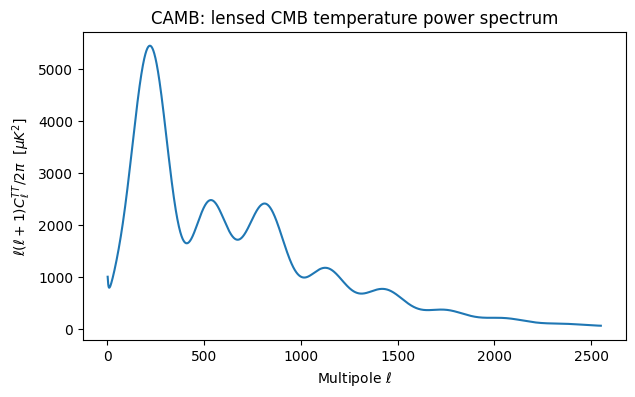

In [3]:
pars.set_for_lmax(2500, lens_potential_accuracy=1)
results = camb.get_results(pars)
powers = results.get_cmb_power_spectra(pars, CMB_unit='muK')
totCL = powers['total']  # columns: TT, EE, BB, TE

ell = np.arange(totCL.shape[0])
plt.figure(figsize=(7, 4))
plt.plot(ell[2:], totCL[2:, 0])
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\ell(\ell+1)C_\ell^{TT}/2\pi\ \ [\mu K^2]$')
plt.title('CAMB: lensed CMB temperature power spectrum')
plt.show()


### 1b. Linear & non-linear matter power spectrum

Note: redshifts have been re-sorted (earliest first)


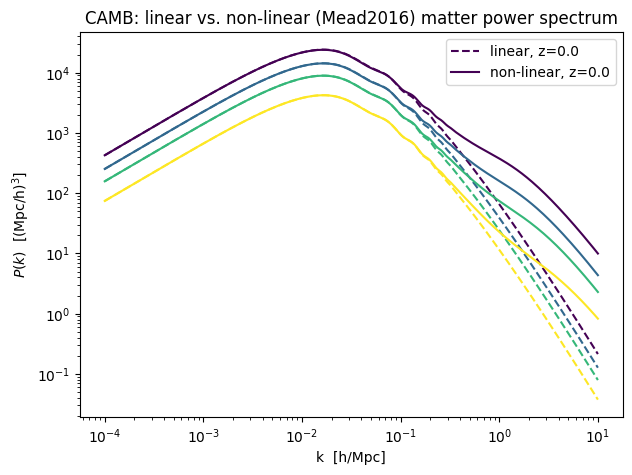

In [4]:
z_list = [0.0, 0.5, 1.0, 2.0]
pars.set_matter_power(redshifts=z_list, kmax=10.0)

# Linear
pars.NonLinear = camb.model.NonLinear_none
results_lin = camb.get_results(pars)
kh_lin, z_lin, pk_lin = results_lin.get_matter_power_spectrum(minkh=1e-4, maxkh=10, npoints=300)

# Non-linear (HMcode / Mead et al. 2016)
pars.NonLinear = camb.model.NonLinear_both
pars.NonLinearModel.set_params(halofit_version='mead2016')
results_nl = camb.get_results(pars)
kh_nl, z_nl, pk_nl = results_nl.get_matter_power_spectrum(minkh=1e-4, maxkh=10, npoints=300)

plt.figure(figsize=(7, 5))
colors = plt.cm.viridis(np.linspace(0, 1, len(z_list)))
for i, zi in enumerate(z_list):
    plt.loglog(kh_lin, pk_lin[i], color=colors[i], ls='--',
               label=f'linear, z={zi}' if i == 0 else None)
    plt.loglog(kh_nl, pk_nl[i], color=colors[i], ls='-',
               label=f'non-linear, z={zi}' if i == 0 else None)
plt.xlabel('k  [h/Mpc]')
plt.ylabel(r'$P(k)$  [(Mpc/h)$^3$]')
plt.title('CAMB: linear vs. non-linear (Mead2016) matter power spectrum')
plt.legend()
plt.show()


## 2. CosmoPower

CosmoPower's `cosmopower_NN` class loads a small neural network that was trained to map
cosmological parameters directly to a (log-)power spectrum, bypassing the Boltzmann solve
entirely. We use the paper's official pre-trained matter-power-spectrum emulators:

* `PKLIN_NN` — linear $P(k)$
* `PKNLBOOST_NN` — the non-linear/linear boost (trained against HMcode, same as CAMB's `mead2016`
  option above), so `nonlinear = linear * boost`

Note the **unit convention differs from CAMB**: CosmoPower's grid is in $\mathrm{Mpc}^{-1}$ /
$\mathrm{Mpc}^3$ (no factors of $h$), so we convert CAMB's `kh`/`Pk` (which are in $h$/Mpc and
$(\mathrm{Mpc}/h)^3$) before comparing.


> **Compatibility note:** `cosmopower`'s pre-trained `.pkl` files were saved years ago and hard-code
> an old TensorFlow internal module path (`tensorflow.python.training.tracking`) that TF removed in
> 2.14. `cosmopower`'s own dependency pin (`tensorflow<2.14`) has no wheel for Colab's current
> Python 3.12 runtime, so we can't just downgrade our way out of it. The cell below installs a
> small import redirect instead, so unpickling still finds those classes under their current
> location (`tensorflow.python.trackable`). This is only needed for the pickle-based `cosmopower`
> package, not for `cosmopower-jax` (used in Section 3), which stores weights as plain `.npz`.


In [5]:
import sys
import importlib
import importlib.abc
import importlib.util

# TF >=2.14 renamed/moved `tensorflow.python.training.tracking` to
# `tensorflow.python.trackable` (and `tracking.py` -> `autotrackable.py` within it).
# CosmoPower's pickled emulators reference the old dotted path, so pickle.load's
# class lookup fails on modern TF unless we redirect it. See:
# https://github.com/alessiospuriomancini/cosmopower/issues/22
_OLD_PREFIX = "tensorflow.python.training.tracking"
_NEW_PREFIX = "tensorflow.python.trackable"
_RENAMES = {"tracking": "autotrackable"}


class _TFCompatLoader(importlib.abc.Loader):
    def __init__(self, target_name):
        self.target_name = target_name

    def create_module(self, spec):
        return importlib.import_module(self.target_name)

    def exec_module(self, module):
        pass  # already fully initialized by create_module


class _TFCompatFinder(importlib.abc.MetaPathFinder):
    def find_spec(self, name, path, target=None):
        if name != _OLD_PREFIX and not name.startswith(_OLD_PREFIX + "."):
            return None
        suffix = name[len(_OLD_PREFIX):].lstrip(".")
        parts = suffix.split(".") if suffix else []
        if parts:
            parts[0] = _RENAMES.get(parts[0], parts[0])
        target_name = ".".join([_NEW_PREFIX] + parts) if parts else _NEW_PREFIX
        try:
            importlib.import_module(target_name)
        except ImportError:
            return None
        return importlib.util.spec_from_loader(name, _TFCompatLoader(target_name))


sys.meta_path.insert(0, _TFCompatFinder())
print("TensorFlow trackable-module compatibility shim installed.")


TensorFlow trackable-module compatibility shim installed.


In [6]:
import cosmopower as cp

pk_dir = 'cosmopower_repo/cosmopower/trained_models/CP_paper/PK'

lin_emu = cp.cosmopower_NN(restore=True, restore_filename=f'{pk_dir}/PKLIN_NN')
nlboost_emu = cp.cosmopower_NN(restore=True, restore_filename=f'{pk_dir}/PKNLBOOST_NN')
k_modes = np.loadtxt(f'{pk_dir}/k_modes.txt')  # Mpc^-1, the fixed grid the NN was trained on

n = len(z_list)
params_lin = {
    'omega_b': [ombh2] * n,
    'omega_cdm': [omch2] * n,
    'h': [h] * n,
    'n_s': [ns] * n,
    'ln10^{10}A_s': [float(np.log(As * 1e10))] * n,
    'z': z_list,
}
# Standard HMcode2016 dark-matter-only baryon-feedback calibration (Mead et al. 2016, Table 2) -
# the same defaults CAMB's 'mead2016' halofit_version uses internally.
params_nlboost = {**params_lin, 'c_min': [3.13] * n, 'eta_0': [0.603] * n}

log_pk_lin = lin_emu.predictions_np(params_lin)
log_boost = nlboost_emu.predictions_np(params_nlboost)
pk_cp_lin = 10.0 ** log_pk_lin
pk_cp_nl = 10.0 ** (log_pk_lin + log_boost)

print(pk_cp_nl.shape)  # (len(z_list), len(k_modes))


(4, 420)


### 2a. CosmoPower vs. CAMB, same cosmology

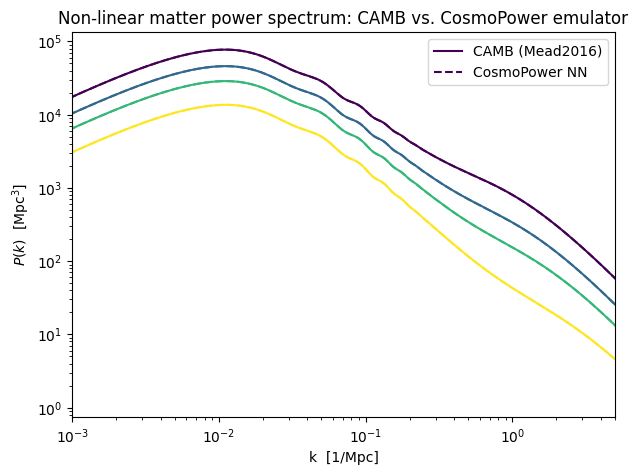

In [7]:
plt.figure(figsize=(7, 5))
for i, zi in enumerate(z_list):
    plt.loglog(kh_nl * h, pk_nl[i] / h**3, color=colors[i], ls='-',
               label='CAMB (Mead2016)' if i == 0 else None)
    plt.loglog(k_modes, pk_cp_nl[i], color=colors[i], ls='--',
               label='CosmoPower NN' if i == 0 else None)
plt.xlim(1e-3, 5)
plt.xlabel('k  [1/Mpc]')
plt.ylabel(r'$P(k)$  [Mpc$^3$]')
plt.title('Non-linear matter power spectrum: CAMB vs. CosmoPower emulator')
plt.legend()
plt.show()


### 2b. Why bother: a speed comparison

In [12]:
import time

n_samples = 10
rng = np.random.default_rng(42)
# draws within the emulator's trained parameter ranges
omb_s = rng.uniform(0.01875, 0.02625, n_samples)
omc_s = rng.uniform(0.05, 0.255, n_samples)
h_s = rng.uniform(0.64, 0.82, n_samples)
ns_s = rng.uniform(0.84, 1.1, n_samples)
lnAs_s = rng.uniform(1.61, 3.91, n_samples)

params_batch = {
    'omega_b': omb_s, 'omega_cdm': omc_s, 'h': h_s, 'n_s': ns_s,
    'ln10^{10}A_s': lnAs_s, 'z': np.zeros(n_samples),
}

t0 = time.time()
_ = lin_emu.predictions_np(params_batch)
t_cp = time.time() - t0
print(f'CosmoPower: {n_samples} P(k) predictions in {t_cp:.4f} s')

t0 = time.time()
for i in range(n_samples):
    print("Working with CAMB in n_sample: ", i+1)
    p = camb.set_params(H0=100 * h_s[i], ombh2=omb_s[i], omch2=omc_s[i],
                         As=np.exp(lnAs_s[i]) * 1e-10, ns=ns_s[i])
    p.set_matter_power(redshifts=[0.0], kmax=2.0)
    r = camb.get_results(p)
    _ = r.get_matter_power_spectrum(minkh=1e-4, maxkh=1, npoints=100)
t_camb = time.time() - t0
print(f'CAMB: {n_samples} P(k) calls in {t_camb:.4f} s')
print(f'Speed-up: {t_camb / t_cp:,.0f}x')


CosmoPower: 10 P(k) predictions in 0.0232 s
Working with CAMB in n_sample:  1
Working with CAMB in n_sample:  2
Working with CAMB in n_sample:  3
Working with CAMB in n_sample:  4
Working with CAMB in n_sample:  5
Working with CAMB in n_sample:  6
Working with CAMB in n_sample:  7
Working with CAMB in n_sample:  8
Working with CAMB in n_sample:  9
Working with CAMB in n_sample:  10
CAMB: 10 P(k) calls in 40.0389 s
Speed-up: 1,729x


## 3. `cloelib`: one interface, two backends

`cloelib` defines each theory code as a `Background` + `Perturbations` pair implementing a common
API (`hubble_parameter`, `comoving_distance`, `matter_power_spectrum`, `growth_factor`, ...). Below
we build a single `CAMBBackground` for our fiducial cosmology, then compute the matter power
spectrum from it through **two different engines**:

* `CAMBLinearPerturbations` / `CAMBNonLinearPerturbations` — runs CAMB directly (same as Section 1).
* `CosmoPowerJAXLCDMPerturbations.Linear` / `.NonLinear` — runs the
  [`cosmopower-jax`](https://github.com/dpiras/cosmopower-jax) emulator (a JAX reimplementation of
  CosmoPower's trained networks). Its first call downloads the pre-trained emulator weights from
  Zenodo, so it may take a few seconds the first time.

This is `cloelib`'s point: downstream Euclid-observable code written against the `Perturbations`
interface doesn't care which of these actually produced the numbers.


In [14]:
from cloelib.cosmology.camb_cosmology import (
    CAMBBackground, CAMBLinearPerturbations, CAMBNonLinearPerturbations,
)
from cloelib.cosmology.cosmopower_jax_cosmology import CosmoPowerJAXLCDMPerturbations

Omega_b0 = ombh2 / h**2
Omega_cdm0 = omch2 / h**2

background = CAMBBackground(H0=H0, Omega_b0=Omega_b0, Omega_cdm0=Omega_cdm0,
                             Omega_k0=0.0, As=As, ns=ns, mnu=0.0,
                             w0=-1.0, wa=0.0, gamma_MG=0.0, N_mnu=0)

z_arr = np.linspace(0.0, 2.0, 20)
ks = np.logspace(-3, 1, 200)

# --- Backend 1: cloelib driving CAMB directly ---
camb_linear = CAMBLinearPerturbations(background=background, redshifts=z_arr)
camb_nonlinear = CAMBNonLinearPerturbations(background=background, linearperturbations=camb_linear, redshifts=z_arr,
                                             nonlinear_model='mead2016')
pk_camb_lin = camb_linear.matter_power_spectrum(z_arr, ks)
pk_camb_nl = camb_nonlinear.matter_power_spectrum(z_arr, ks)

# --- Backend 2: cloelib driving the CosmoPower-JAX emulator, off the *same* background ---
cp_linear = CosmoPowerJAXLCDMPerturbations.Linear(background=background, redshifts=z_arr)
cp_nonlinear = CosmoPowerJAXLCDMPerturbations.NonLinear(
    background=background, linearperturbations=cp_linear, redshifts=z_arr, log10TAGN=7.6,
)
pk_cp_lin = cp_linear.matter_power_spectrum(z_arr, ks)
pk_cp_nl = cp_nonlinear.matter_power_spectrum(z_arr, ks)

print('CAMB backend :', camb_nonlinear)
print('CosmoPower-JAX backend :', cp_nonlinear)


Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)
CAMB backend : <cloelib.cosmology.camb_cosmology.CAMBNonLinearPerturbations object at 0x79068d6da3c0>
CosmoPower-JAX backend : Cosmopower-JAX nonlinear P(k) module for LCDM cosmology.
Configuration: N_mnu=0, no massive neutrinos.


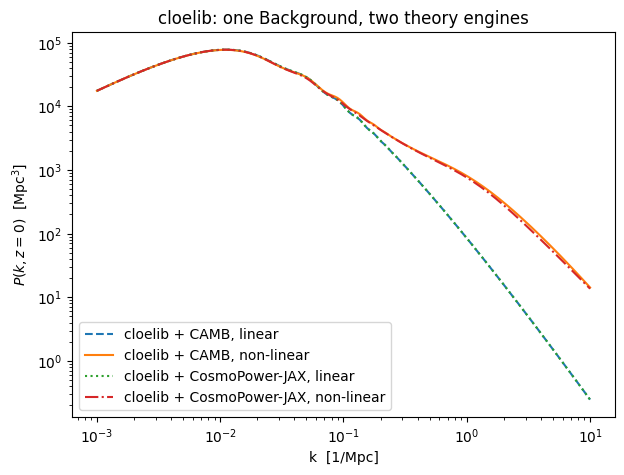

In [15]:
iz = 0  # z = 0 slice

plt.figure(figsize=(7, 5))
plt.loglog(ks, pk_camb_lin[iz], label='cloelib + CAMB, linear', ls='--')
plt.loglog(ks, pk_camb_nl[iz], label='cloelib + CAMB, non-linear', ls='-')
plt.loglog(ks, pk_cp_lin[iz], label='cloelib + CosmoPower-JAX, linear', ls=':')
plt.loglog(ks, pk_cp_nl[iz], label='cloelib + CosmoPower-JAX, non-linear', ls='-.')
plt.xlabel('k  [1/Mpc]')
plt.ylabel(r'$P(k, z=0)$  [Mpc$^3$]')
plt.title('cloelib: one Background, two theory engines')
plt.legend()
plt.show()


### 3a. Growth rate, both ways

Both backends also expose the linear growth rate $f(z)$ through the same method name, again
computed from the one shared `background`.


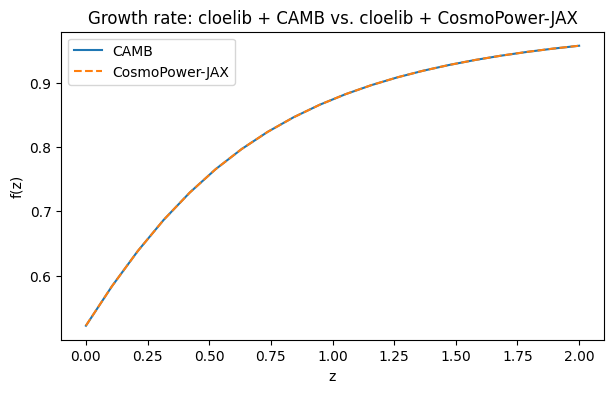

In [16]:
plt.figure(figsize=(7, 4))
plt.plot(z_arr, camb_linear.growth_rate(), label='CAMB', ls='-')
plt.plot(z_arr, cp_linear.growth_rate(), label='CosmoPower-JAX', ls='--')
plt.xlabel('z')
plt.ylabel('f(z)')
plt.title('Growth rate: cloelib + CAMB vs. cloelib + CosmoPower-JAX')
plt.legend()
plt.show()


## References

* CAMB — [Lewis, Challinor & Lasenby 2000](https://arxiv.org/abs/astro-ph/9911177); code &
  docs: <https://camb.readthedocs.io>
* CosmoPower — [Spurio Mancini et al. 2022](https://arxiv.org/abs/2106.03846); code:
  <https://github.com/alessiospuriomancini/cosmopower>; JAX version:
  <https://github.com/dpiras/cosmopower-jax>
* `cloelib` — Euclid Collaboration, *The Library for Cosmology Likelihood for Observables in Euclid* actively-maintained code:
  <https://github.com/cloe-org/cloelib>; full likelihood/sampler wrapper:
  <https://github.com/cloe-org/cloelike>.
